# Multicomponent test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [52]:
# read the data
import pandas as pd
galname = 'J2212_comp'
j2212_comp = pd.read_csv(galname + '.csv')

wave = j2212_comp['wave'].to_numpy()
flux = j2212_comp['flux'].to_numpy()
err = j2212_comp['noise'].to_numpy()
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# [NII]6548 + Ha + [NII]6584
select = (wave > 7695) * (wave < 7765)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# Hb + [OIII]4959 + [OIII]5007
select = (wave > 5880) * (wave < 5910)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])

(-1e-16, 1e-15)

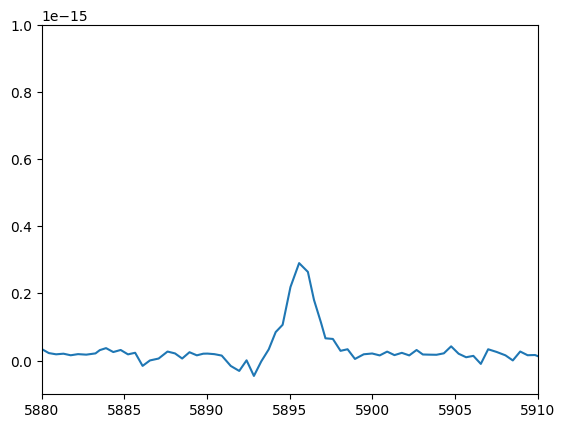

In [35]:
plt.plot(wave, flux)
plt.xlim(5880, 5910)
plt.ylim(-0.1e-15, 0.1e-14)
#plt.yscale('log')

# Single gaussian component

## [NII]6548 + H$\alpha$ + [NII]6584

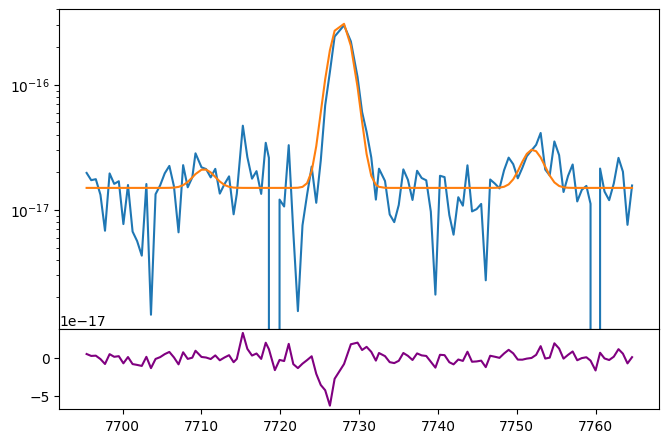

In [45]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 1.5e-17

ha = gaussian(ha_nii.wavelength, 0.1e-14, wave_cat['Ha'], z=z_BN[igal]+0.0005, sigma = 1.3)
niib = gaussian(ha_nii.wavelength, 0.1e-14 * 0.02, wave_cat['[NII]6548'], z=z_BN[igal]+0.0005, sigma = 1.3)
niia = gaussian(ha_nii.wavelength, 0.1e-14 * 0.05, wave_cat['[NII]6584'], z=z_BN[igal]+0.0005, sigma = 1.3)

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia)
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')
ax.set_yscale('log')

In [46]:
params_ha_nii = Parameters()

params_ha_nii.add('z', value=z_BN[igal]+0.0005)
params_ha_nii.add('sigma', value=1.3, min=0.)
params_ha_nii.add('Ha_flux', value=0.1e-14, min=0.)
params_ha_nii.add('Niib_to_Ha', value=0.02, min=0., max=1.)
params_ha_nii.add('Niia_to_Ha', value=0.05, min=0., max=1.)
params_ha_nii.add('bkg', value=1.5e-17, min=0.)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z = params_ha_nii['z']
    sigma = params_ha_nii['sigma']
    ha_flux = params_ha_nii['Ha_flux']
    niia_flux = ha_flux * params_ha_nii['Niia_to_Ha']
    niib_flux = ha_flux * params_ha_nii['Niib_to_Ha']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    model = gaussian(x, niib_flux, wave_cat['[NII]6548'], z, sigma) + gaussian(x, ha_flux, wave_cat['Ha'], z, sigma) + gaussian(x, niia_flux, wave_cat['[NII]6584'], z, sigma)
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [47]:
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 116.18it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [47.67473995 52.74795551 62.18030269 67.94304747 72.77731288 57.75489228]


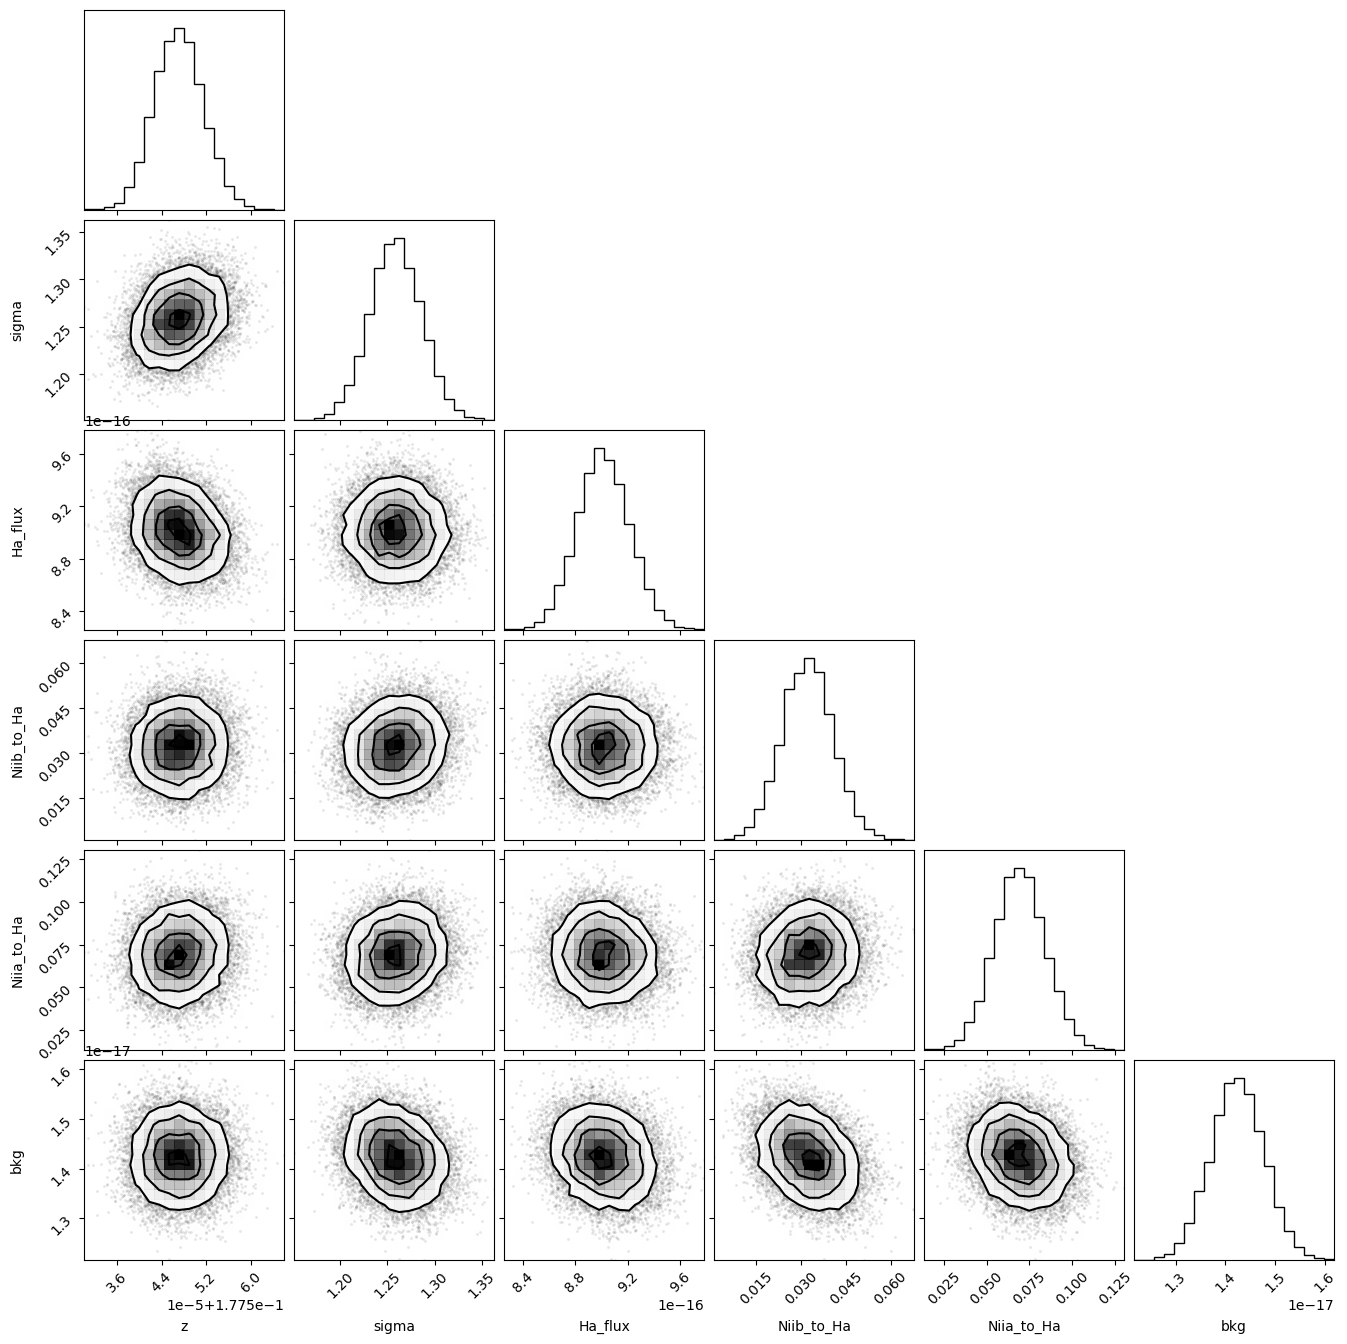

In [48]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);

In [49]:
out_ha_nii

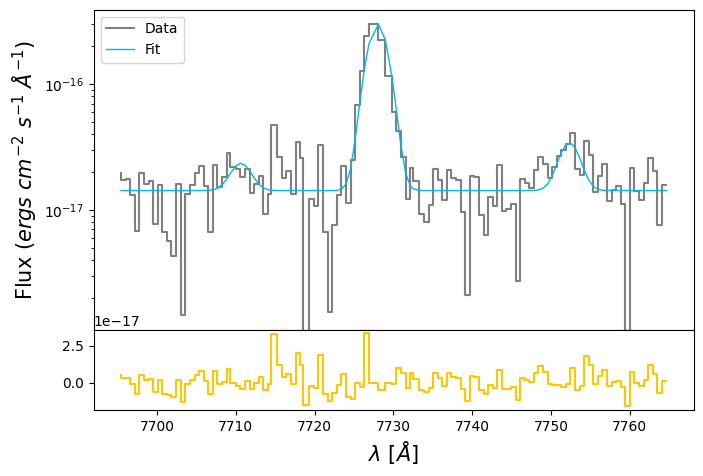

In [50]:
ha_flux = out_ha_nii.flatchain.Ha_flux.mean()
ha_std = out_ha_nii.flatchain.Ha_flux.std()

niia_flux = (ha_flux * out_ha_nii.flatchain.Niia_to_Ha).mean()
niia_std = (ha_flux * out_ha_nii.flatchain.Niia_to_Ha).std()

niib_flux = (ha_flux * out_ha_nii.flatchain.Niib_to_Ha).mean()
niib_std = (ha_flux * out_ha_nii.flatchain.Niib_to_Ha).std()

bkg_ha_nii = out_ha_nii.flatchain.bkg.mean()
z_ha_nii = out_ha_nii.flatchain.z.mean()
sigma_ha_nii = out_ha_nii.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data')

ha = gaussian(ha_nii.wavelength, ha_flux, wave_cat['Ha'], z_ha_nii, sigma_ha_nii)
niia = gaussian(ha_nii.wavelength, niia_flux, wave_cat['[NII]6584'], z_ha_nii, sigma_ha_nii)
niib = gaussian(ha_nii.wavelength, niib_flux, wave_cat['[NII]6548'], z_ha_nii, sigma_ha_nii)

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')
ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
#ax.text(x=7008, y=1.5e-13, s=r'[NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584',
#       fontsize=15)
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

## [OIII]5007 + HeI 5015

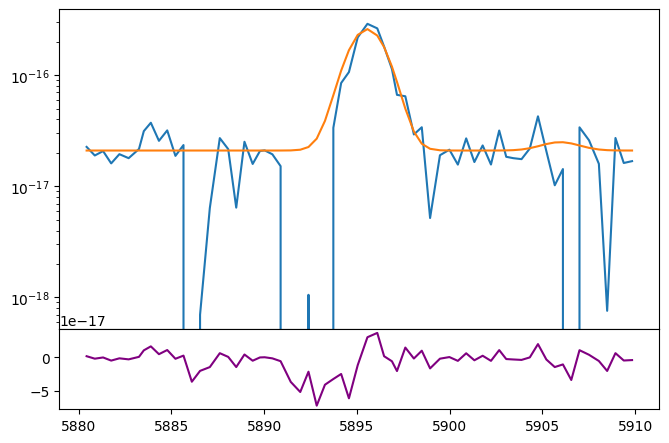

In [61]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_hei.wavelength, oiii_hei.flux)
bkg = 2.1e-17

oiii = gaussian(oiii_hei.wavelength, 0.6e-15, wave_cat['[OIII]5007'], z=z_BN[igal]+0.0005, sigma=1.0)
hei = gaussian(oiii_hei.wavelength, 0.1e-16, wave_cat['HeI5015'], z=z_BN[igal]+0.0005, sigma=1.0)

ax.plot(oiii_hei.wavelength, bkg + oiii + hei)
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg - oiii - hei, color='purple')
ax.set_yscale('log')

In [68]:
params_oiii_hei = Parameters()
params_oiii_hei.add('z', value=z_BN[igal]+0.0005)
params_oiii_hei.add('sigma', value=1.0, min=0.)
params_oiii_hei.add('Oiii_flux', value=0.6e-15, min=0.)
params_oiii_hei.add('Hei_to_oiii', value=0.1e-16, min=0., max=1.)
params_oiii_hei.add('bkg', value=2.1e-17, min=0.)


def residual_oiii_hei(params_oiii_hei, x, data, uncertainty):
    
    z = params_oiii_hei['z']
    sigma = params_oiii_hei['sigma']
    oiii_flux = params_oiii_hei['Oiii_flux']
    hei_flux = oiii_flux * params_oiii_hei['Hei_to_oiii']
    bkg = params_oiii_hei['bkg']
    
    x = oiii_hei.wavelength
    model = gaussian(x, oiii_flux, wave_cat['[OIII]5007'], z, sigma) + gaussian(x, hei_flux, wave_cat['HeI5015'], z, sigma)
    
    return (model + bkg - oiii_hei.flux) / oiii_hei.noise

In [69]:
out_oiii_hei = minimize(residual_oiii_hei, params_oiii_hei, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:16<00:00, 154.93it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 47.4008582   53.15767728  47.0011228  260.43322732  58.65299869]


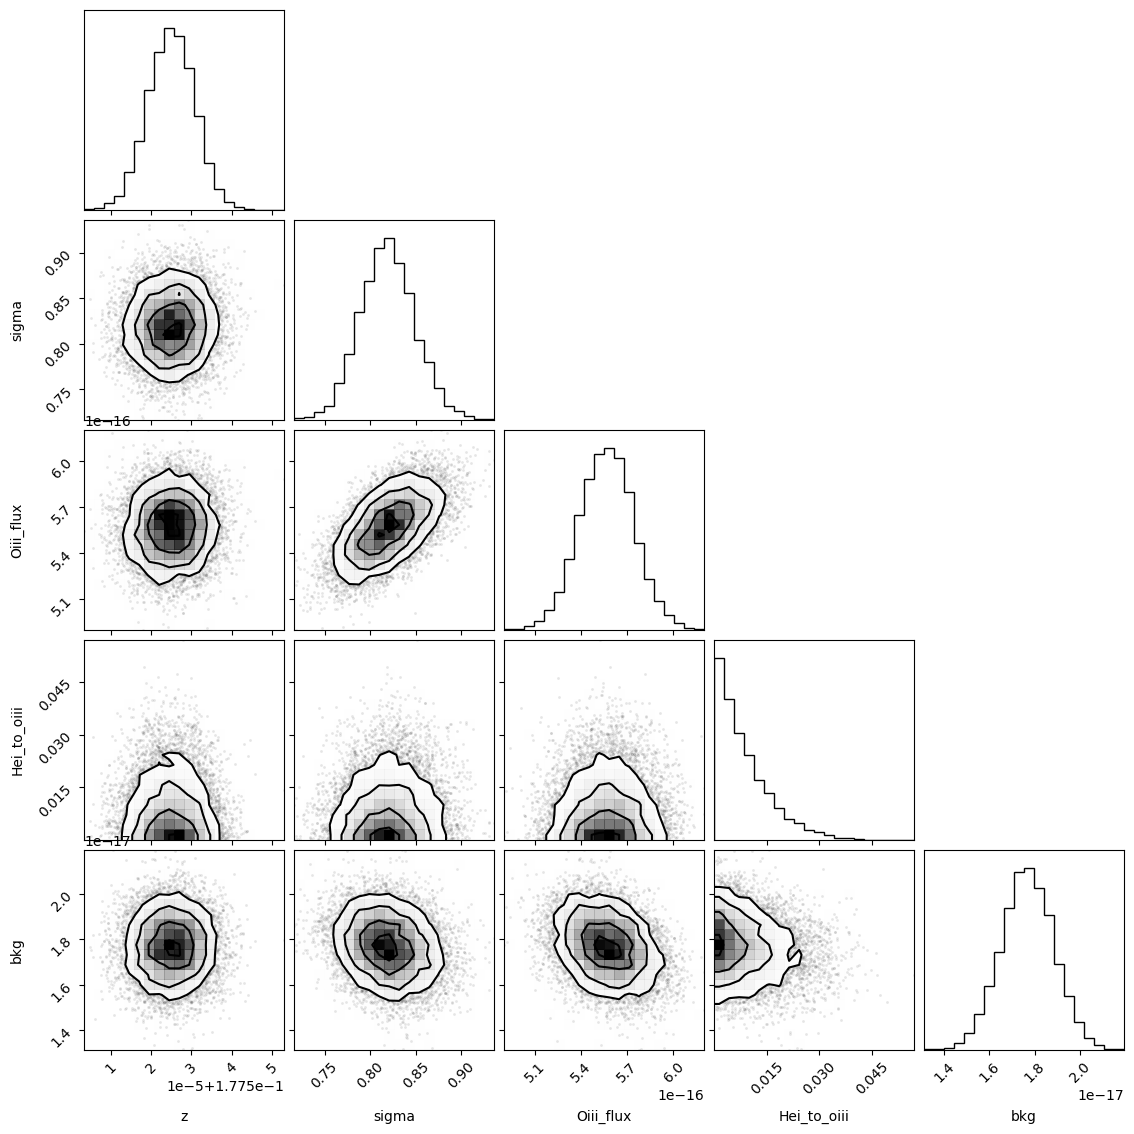

In [70]:
corner.corner(out_oiii_hei.flatchain, labels=out_oiii_hei.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [71]:
out_oiii_hei

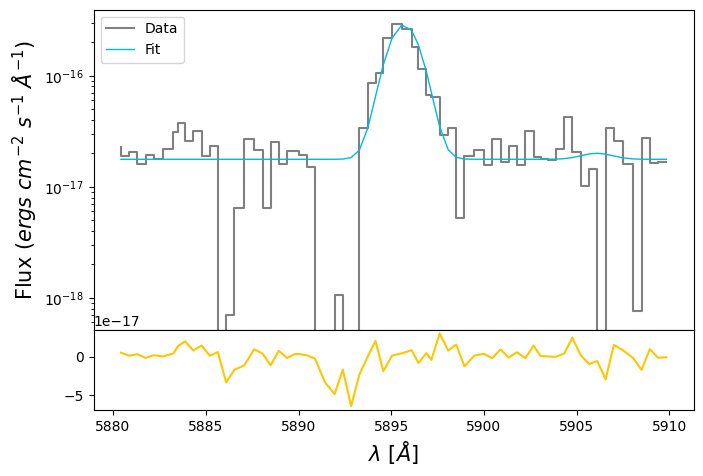

In [72]:
oiii_flux = out_oiii_hei.flatchain.Oiii_flux.mean()
oiii_std = out_oiii_hei.flatchain.Oiii_flux.std()

hei_flux = oiii_flux * out_oiii_hei.flatchain.Hei_to_oiii.mean()
hei_std = oiii_flux * out_oiii_hei.flatchain.Hei_to_oiii.std()

bkg_oiii_hei = out_oiii_hei.flatchain.bkg.mean()
z_oiii_hei = out_oiii_hei.flatchain.z.mean()
sigma_oiii_hei = out_oiii_hei.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_hei.wavelength, oiii_hei.flux,
            color='gray', label='Data')

oiii = gaussian(oiii_hei.wavelength, oiii_flux, wave_cat['[OIII]5007'], z_oiii_hei, sigma_oiii_hei)
hei = gaussian(oiii_hei.wavelength, hei_flux, wave_cat['HeI5015'], z_oiii_hei, sigma_oiii_hei)

ax.plot(oiii_hei.wavelength, bkg_oiii_hei + oiii + hei,
        lw=1, color=c[0], label='Fit')
ax1.plot(oiii_hei.wavelength, oiii_hei.flux - bkg_oiii_hei - oiii - hei,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')